In [1]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import wkls
from reusable import *

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sedonadb\context.py:520: UserWarning: Failed to configure PROJ. Is pyproj or a system install of PROJ available?
Details: tried ['pyproj', 'conda', 'homebrew', 'system']
pyproj: Expected PROJ dll/so directory 'd:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\pyproj.libs' does not exist
conda: Can't load PROJ shared library 'D:\hp\Documents\Scripts\r5py\.conda\lib\libproj.dylib': Could not find module 'D:\hp\Documents\Scripts\r5py\.conda\lib\libproj.dylib' (or one of its dependencies). Try using the full path with constructor syntax.
homebrew: Can't configure PROJ from prefix '\opt\homebrew': does not exist
system: Can't load PROJ shared library 'proj.dll': Could not find module 'proj.dll' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(


### **Boundaries and setup**

In [ ]:
osm_path = r"sample_cities/tallinn/est_pop_2015_CN_100m_R2025A_v1.tif"
gtfs_path = r"sample_cities/tallinn/mdb-3047-202603010109.zip"
pop_path = r"sample_cities/tallinn/est_pop_2015_CN_100m_R2025A_v1.tif"

In [3]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()

In [4]:
tallinn = boundaries[
    (boundaries["boundary"] == "administrative") &
    (boundaries["admin_level"].astype(str).str.match(r"^(6|8|9)$")) &
    (boundaries["name"].str.contains("Tallinn", case=False, na=False))
]

In [5]:
tallinn.sort_values(by="admin_level", ascending=False).head(20)

,name,admin_level,boundary,postal_code,id,timestamp,version,changeset,geometry,tags,osm_type
11,Põhja-Tallinna linnaosa,9,administrative,None,6118553,1766310046,32,176209493,"MULTIPOLYGON (((24.64593 59.46944, 24.64597 59...","{""EHAK:code"":""0614"",""EHAK:countycode"":""0037"",""...",relation
137,Tallinn,8,administrative,None,766795072,1766310046,66,176209493,"MULTIPOLYGON (((24.55027 59.43882, 24.55054 59...","{""EHAK:code"":""0784"",""EHAK:countycode"":""0037"",""...",relation


In [6]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

In [7]:
city_proj = tallinn.copy()
city_proj = city_proj.dissolve()
city_proj = city_proj.to_crs(city_proj.estimate_utm_crs())

<Axes: >

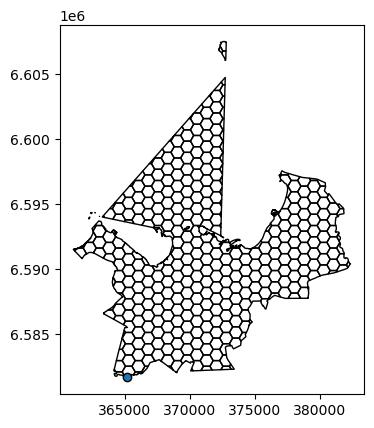

In [8]:
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  410,159
Hex grid total population: 409,606
Coverage: 99.9%


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 9 classes. Setting k to 8.
  self.bins = quantile(y, k=k)


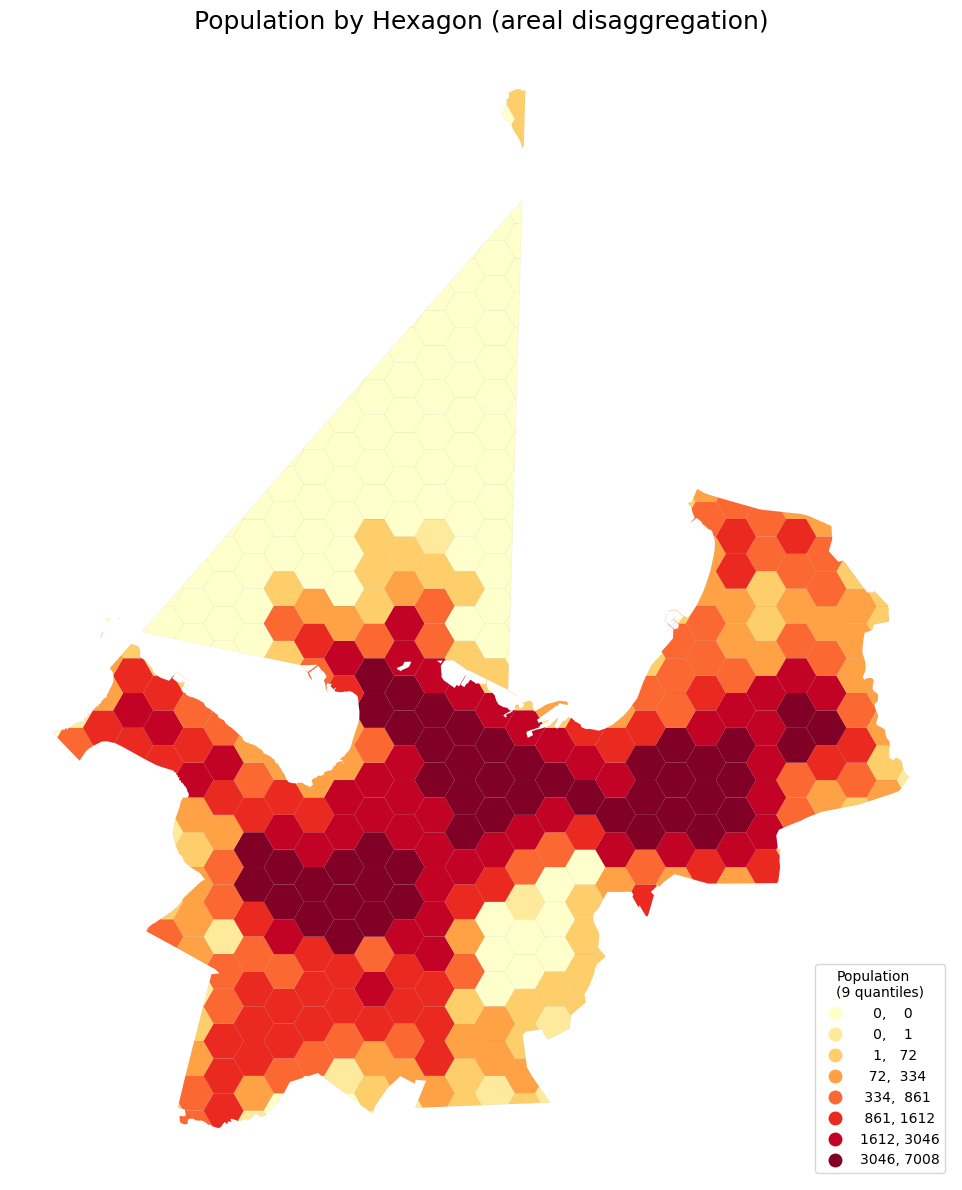

In [9]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

In [10]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/tallinn_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

City-wide baseline distribution:
  count_community: 0.032
  count_education: 0.098
  count_essential_services: 0.088
  count_food_and_drink: 0.461
  count_healthcare: 0.108
  count_shelter: 0.213


#### **Origins**

In [22]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (2.32454 48.82159),0,7904.347682
1,POINT (2.29504 48.82687),1,1386.568600
2,POINT (2.31385 48.82469),2,10868.960602
3,POINT (2.335 48.81821),3,5448.822324
4,POINT (2.35519 48.81808),4,9305.753689


#### **Destinations (POIs)**

In [23]:
destinations = create_POIs(osm, summary=True)

Total amenities: 83872

By type:
amenity class
food_and_drink        28378
education              9748
healthcare             7091
essential_services     5546
motorcycle_parking     3526
ticket_validator       2877
community              2793
drinking_water         2254
toilets                2079
shelter                1963


#### **Results and Visualisation**

Define categories of interest among the amenity classes to measure

In [24]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']
essentials = destinations[destinations['amenity class'].isin(categories)]

Compute travel time matrix between all origins and points of interest, deifining threshold for max. travel time and modes of transport

In [25]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=20) #CUTOFF
)

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\r5py\r5\regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2026-04-30.
  warnings.warn(


Calculate score for basic metrics (minimum travel time, basic counts (no gravity), weighted counts (gravity))

In [26]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)

In [27]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)

In [28]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0644)

Adjusting for population & diversity metric

In [29]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

In [30]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)

City-wide baseline distribution:
  gravity_community: 0.027
  gravity_education: 0.099
  gravity_essential_services: 0.077
  gravity_food_and_drink: 0.687
  gravity_healthcare: 0.099
  gravity_shelter: 0.011


### **Result Plotting**

In [31]:
gravity = merge_geometry(gravity, grid=grid)
res = merge_geometry(min_tt_wide, grid)
pop_weighed = merge_geometry(pop_weighed, grid)
no_gravity = merge_geometry(no_gravity, grid=grid)
diversity = merge_geometry(diversity, grid=grid)

In [32]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 10.
  self.bins = quantile(y, k=k)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment vari

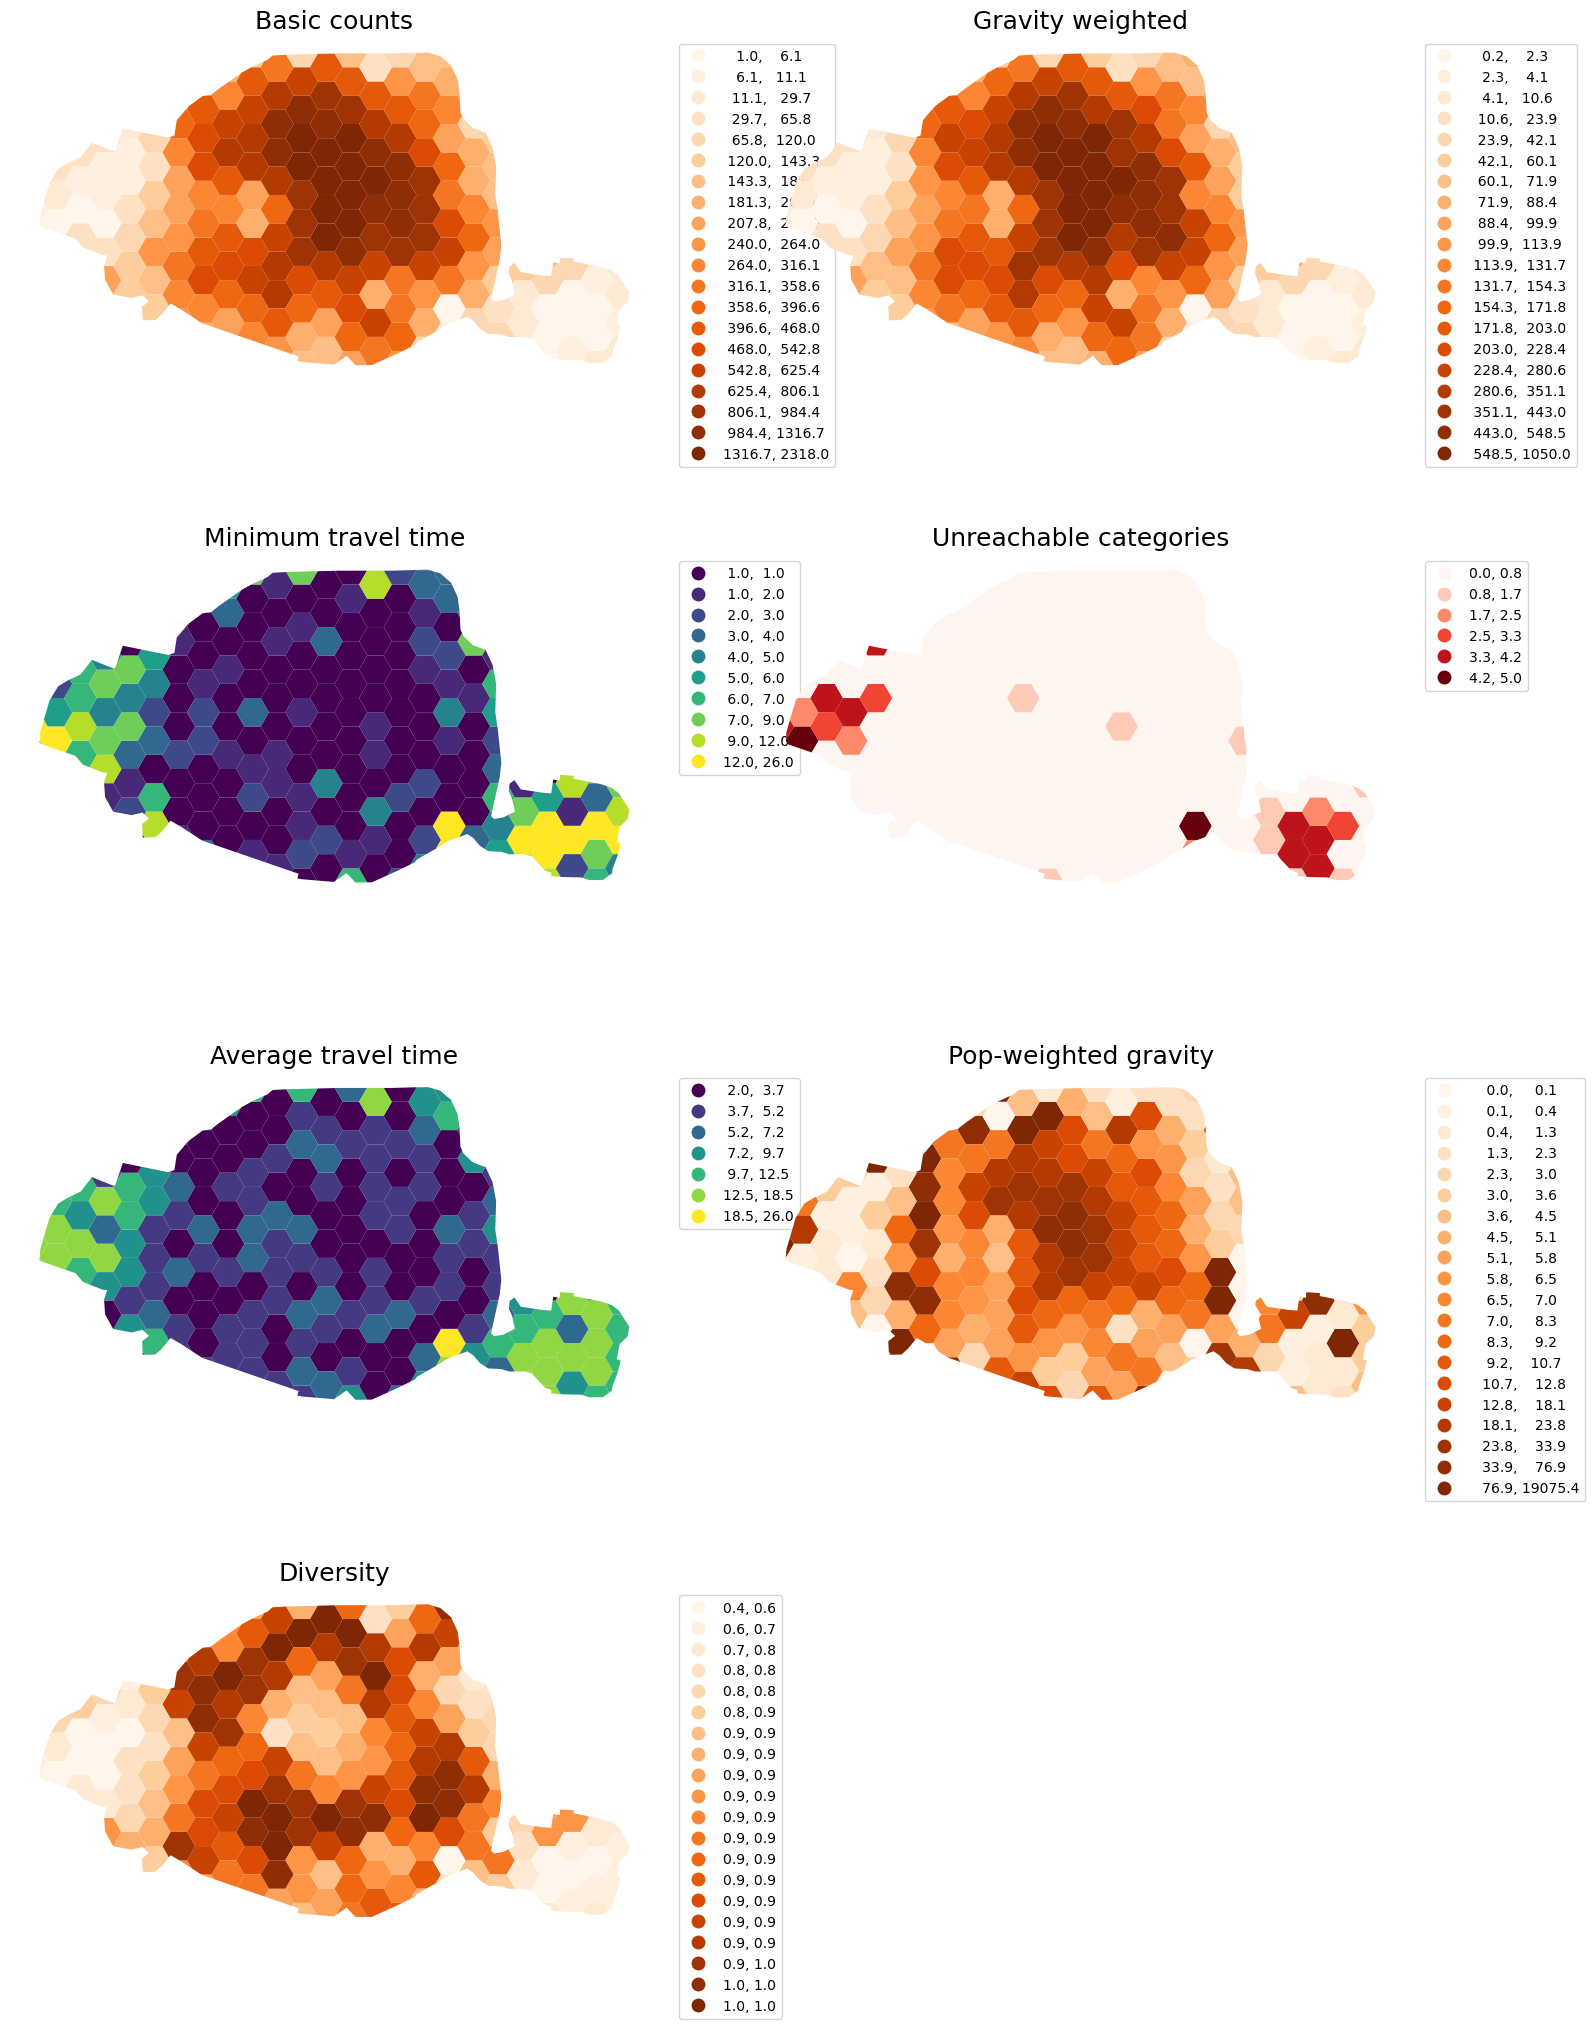

In [33]:
fig = plt.figure(figsize=(18, 26))
gs = fig.add_gridspec(
    nrows=8, ncols=2,
    height_ratios=[12, 1, 12, 1, 12, 1, 12, 1],
    hspace=0.35, wspace=0.15
)

plots = [
    (no_gravity, "gravity_food_and_drink", "Basic counts", "Oranges", "Quantiles", 20),
    (gravity, "gravity_food_and_drink", "Gravity weighted", "Oranges", "Quantiles", 20),
    (res, "min_tt_food_and_drink", "Minimum travel time", "viridis", "Quantiles", 20),
    (res, "n_unreachable_categories", "Unreachable categories", "Reds", "EqualInterval", 6),
    (res, "avg_tt", "Average travel time", "viridis", "NaturalBreaks", 7),
    (pop_weighed, "gravity_food_and_drink_per_1000", "Pop-weighted gravity", "Oranges", "Quantiles", 20),
    (diversity, "city_similarity", "Diversity", "Oranges", "Quantiles", 20),
]

for i, (gdf, col, ttl, cmap, scheme, k) in enumerate(plots):
    row = (i // 2) * 2
    col_idx = i % 2

    ax = fig.add_subplot(gs[row, col_idx])

    plot_hex_score(
        gdf,
        score_col=col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        title=ttl,
        ax=ax,
        show=False
    )

if len(plots) % 2 == 1:
    fig.add_subplot(gs[6, 1]).axis("off")
    fig.add_subplot(gs[7, 1]).axis("off")

plt.tight_layout()
fig.savefig("turin_results.png", dpi=300, bbox_inches="tight")

In [36]:
import os, json
import geopandas as gpd

def to_df(gdf):
    if "geometry" in gdf.columns:
        return gdf.drop(columns="geometry")
    return gdf

# ── Rename no_gravity columns: gravity_X → count_X ───────────────────────────

counts = to_df(no_gravity).copy()
counts = counts.rename(columns={
    c: c.replace("gravity_", "count_")
    for c in counts.columns if c.startswith("gravity_")
})
# also rename avg_gravity → avg_count if present
if "avg_gravity" in counts.columns:
    counts = counts.rename(columns={"avg_gravity": "avg_count"})

# ── Merge everything on from_id ───────────────────────────────────────────────

master = (
    to_df(gravity)
    .merge(to_df(min_tt_wide), on="from_id", how="left")
    .merge(to_df(pop_weighed), on="from_id", how="left")
    .merge(to_df(diversity),   on="from_id", how="left")
    .merge(counts,             on="from_id", how="left")   # ← counts added
)

# ── Attach geometry & export ──────────────────────────────────────────────────

master_geo = merge_geometry(master, grid)
master_geo["city"] = "paris"

os.makedirs("data", exist_ok=True)
out = master_geo.to_crs("EPSG:4326").copy()
out["from_id"] = out["from_id"].astype(str)
out.to_file("data/paris_scores.geojson", driver="GeoJSON")

print(f"Features : {len(out)}")
print(f"Count cols: {[c for c in out.columns if c.startswith('count_')]}")
print(f"All cols  : {[c for c in out.columns if c != 'geometry']}")

Features : 202
Count cols: ['count_community', 'count_education', 'count_essential_services', 'count_food_and_drink', 'count_healthcare', 'count_shelter']
All cols  : ['from_id', 'gravity_community', 'gravity_education', 'gravity_essential_services', 'gravity_food_and_drink', 'gravity_healthcare', 'gravity_shelter', 'avg_gravity', 'min_tt_community', 'min_tt_education', 'min_tt_essential_services', 'min_tt_food_and_drink', 'min_tt_healthcare', 'min_tt_shelter', 'avg_tt', 'n_unreachable_categories', 'gravity_food_and_drink_per_1000', 'shannon', 'kl_divergence', 'jsd', 'city_similarity', 'count_community', 'count_education', 'count_essential_services', 'count_food_and_drink', 'count_healthcare', 'count_shelter', 'avg_count', 'city']
